# Backtest Example: Momentum Taker

Runs a simple momentum-following strategy through the full backtest pipeline.

**Prerequisites:**
- `gnome-backtest` uber JAR built: `cd gnome-backtest && mvn package -DskipTests`
- AWS credentials configured + `aws sso login`

In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

from gnomepy.java import (
    ensure_jvm_started,
    Backtest,
    ExchangeConfig,
    StaticFeeConfig,
    StaticLatencyConfig,
    SchemaType,
    Scales,
    RiskConfig,
)
from gnomepy.strategies import MomentumTaker

ensure_jvm_started()

## Configuration

Fill in your exchange, security, and date range.

In [2]:
# --- Fill these in ---
EXCHANGE_ID = 1
SECURITY_ID = 1
START = datetime(2026, 1, 20, 10, 30)
END = datetime(2026, 1, 20, 14, 0)
# ---------------------

## Create Strategy + Run Backtest

In [9]:
strategy = MomentumTaker(
    exchange_id=EXCHANGE_ID,
    security_id=SECURITY_ID,
    lookback=100,
    threshold_bps=5.0,
    order_size=1_000_000,
    cooldown_ticks=50,
)

# Risk config: limit max notional value per order
risk_config = RiskConfig(max_notional_value=10**20)

# Fee model: taker pays 3.5 bps, maker pays 1 bp
fee_model = StaticFeeConfig(taker_fee=0.00035, maker_fee=0.0001)

# Latency assumptions (in nanoseconds)
# Network: 50ms round-trip (strategy ↔ exchange)
# Order processing: 5ms (exchange matching engine)
network_latency = StaticLatencyConfig(latency_nanos=50_000_000)
order_processing_latency = StaticLatencyConfig(latency_nanos=5_000_000)

backtest = Backtest(
    strategy=strategy,
    schema_type=SchemaType.MBP_10,
    start_date=START,
    end_date=END,
    exchanges=[
        ExchangeConfig(
            exchange_id=EXCHANGE_ID,
            security_id=SECURITY_ID,
            fee_model=fee_model,
            network_latency=network_latency,
            order_processing_latency=order_processing_latency,
        ),
    ],
    risk_config=risk_config,
)

results = backtest.run()
print(f"Market records: {results.market_record_count}")
print(f"Execution records: {results.execution_record_count}")
print(f"Strategy fills: {len(strategy.fills)}")

Market records: 68181
Execution records: 16
Strategy fills: 16


## Results Summary

In [10]:
summary = results.summary()
for k, v in summary.items():
    print(f"{k}: {v}")

market_records: 68181
execution_records: 16
total_pnl: -374.34060798358087
total_fees: 418.500492984
max_nmv: 399395.146455
final_quantity: 4.37827
num_fills: 16
num_cancels: 0
num_rejects: 0


## Execution Records

In [11]:
exec_df = results.execution_records_df()
print(f"Shape: {exec_df.shape}")
exec_df.tail(20)

Shape: (16, 12)


,timestamp_recv,exchange_id,security_id,client_oid,side,exec_type,order_status,filled_qty,fill_price,cumulative_qty,leaves_qty,fee
timestamp_event,,,,,,,,,,,,
2026-01-20 12:18:47.951,2026-01-20 12:18:48.006,1,1,oms-1,Ask,FILL,FILLED,1.00000,91101.840610,1.00000,0.00000,31.885644
2026-01-20 12:18:50.777,2026-01-20 12:18:50.832,1,1,oms-2,Ask,PARTIAL_FILL,PARTIALLY_FILLED,0.34140,91100.245518,0.34140,0.65860,10.885568
2026-01-20 12:27:40.352,2026-01-20 12:27:40.407,1,1,oms-3,Bid,FILL,FILLED,1.00000,91126.723580,1.00000,0.00000,31.894353
2026-01-20 13:04:23.628,2026-01-20 13:04:23.683,1,1,oms-4,Ask,PARTIAL_FILL,PARTIALLY_FILLED,0.03357,91006.867441,0.03357,0.96643,1.069285
2026-01-20 13:14:32.833,2026-01-20 13:14:32.888,1,1,oms-5,Bid,FILL,FILLED,1.00000,90870.995600,1.00000,0.00000,31.804848
2026-01-20 13:20:36.543,2026-01-20 13:20:36.598,1,1,oms-6,Bid,FILL,FILLED,1.00000,90986.608810,1.00000,0.00000,31.845313
2026-01-20 13:22:18.652,2026-01-20 13:22:18.707,1,1,oms-7,Ask,FILL,FILLED,1.00000,90922.872920,1.00000,0.00000,31.823006
2026-01-20 13:22:26.114,2026-01-20 13:22:26.169,1,1,oms-8,Ask,FILL,FILLED,1.00000,90917.000000,1.00000,0.00000,31.820950
2026-01-20 13:34:24.861,2026-01-20 13:34:24.916,1,1,oms-9,Bid,PARTIAL_FILL,PARTIALLY_FILLED,0.83385,90811.951286,0.83385,0.16615,26.503241


## Strategy Fills

In [13]:
for f in strategy.fills[:10]:
    price = f.fill_price / Scales.PRICE
    print(f"{f.exec_type.value}: {f.client_oid} side={f.exec_type.value} "
          f"qty={f.filled_qty} @ {price:.4f} fee={f.fee:.6f}")

FILL: oms-1 side=FILL qty=1000000 @ 91101.8406 fee=31885644213500004.000000
PARTIAL_FILL: oms-2 side=PARTIAL_FILL qty=341400 @ 91100.2455 fee=10885568337000000.000000
FILL: oms-3 side=FILL qty=1000000 @ 91126.7236 fee=31894353252999996.000000
PARTIAL_FILL: oms-4 side=PARTIAL_FILL qty=33570 @ 91006.8674 fee=1069285189000000.000000
FILL: oms-5 side=FILL qty=1000000 @ 90870.9956 fee=31804848460000004.000000
FILL: oms-6 side=FILL qty=1000000 @ 90986.6088 fee=31845313083500004.000000
FILL: oms-7 side=FILL qty=1000000 @ 90922.8729 fee=31823005522000000.000000
FILL: oms-8 side=FILL qty=1000000 @ 90917.0000 fee=31820950000000000.000000
PARTIAL_FILL: oms-9 side=PARTIAL_FILL qty=833850 @ 90811.9513 fee=26503240953000000.000000
FILL: oms-10 side=FILL qty=1000000 @ 90865.0000 fee=31802750000000000.000000


## PnL

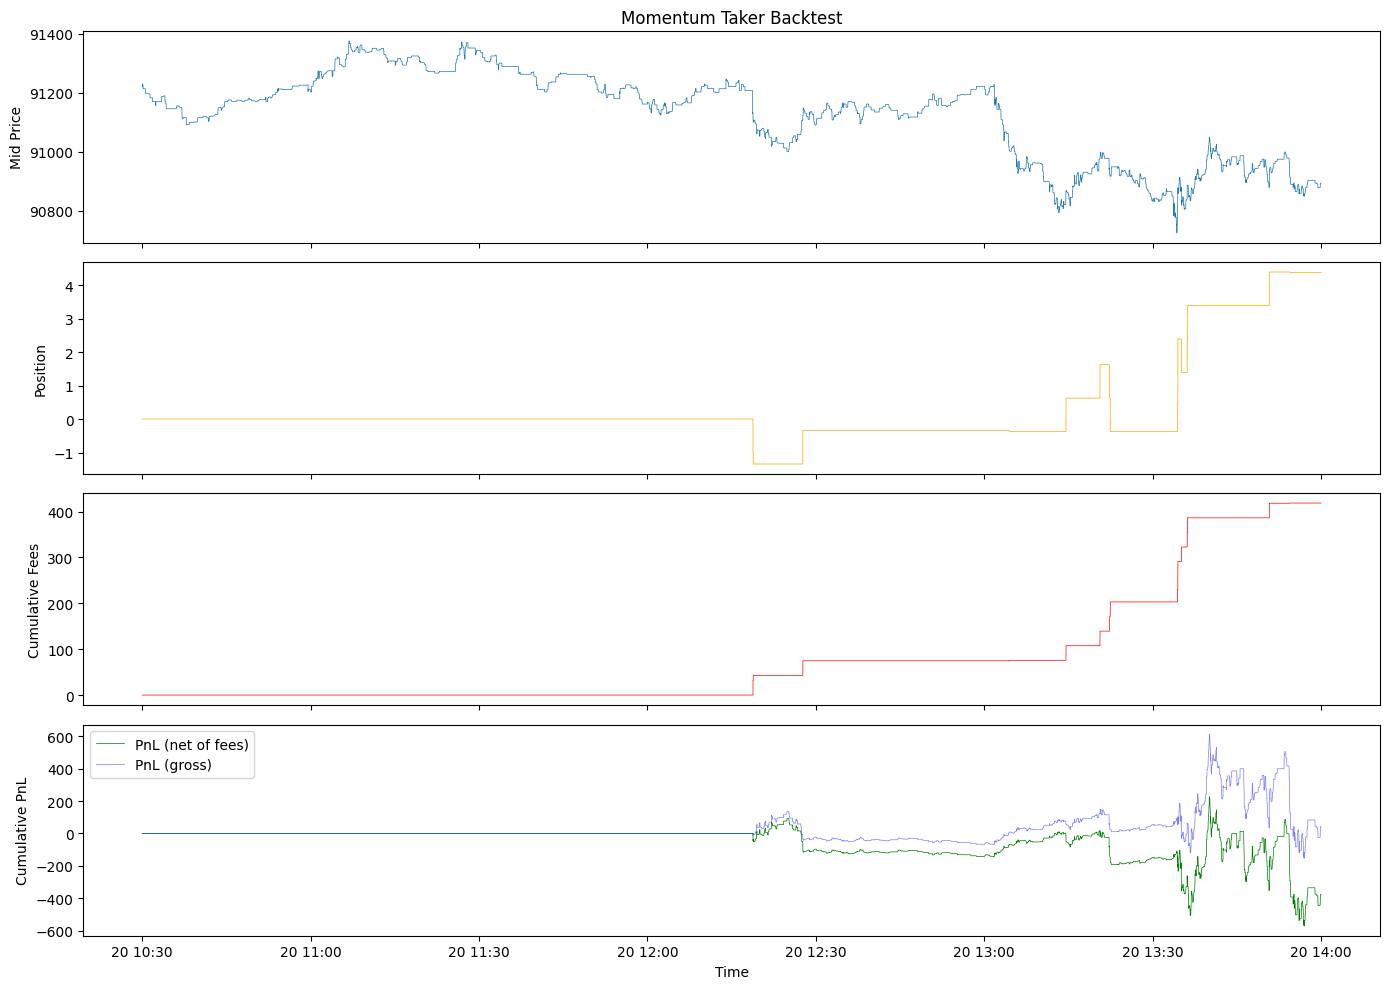

In [14]:
pnl_df = results.compute_pnl()
if not pnl_df.empty:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(pnl_df["price"], linewidth=0.5)
    axes[0].set_ylabel("Mid Price")
    axes[0].set_title("Momentum Taker Backtest")

    axes[1].plot(pnl_df["quantity"], linewidth=0.5, color="orange")
    axes[1].set_ylabel("Position")

    axes[2].plot(pnl_df["fee"], linewidth=0.5, color="red")
    axes[2].set_ylabel("Cumulative Fees")

    axes[3].plot(pnl_df["pnl"], linewidth=0.5, color="green", label="PnL (net of fees)")
    axes[3].plot(pnl_df["holding_pnl"].cumsum() + pnl_df["trade_pnl"].cumsum(),
                 linewidth=0.5, color="blue", alpha=0.5, label="PnL (gross)")
    axes[3].set_ylabel("Cumulative PnL")
    axes[3].set_xlabel("Time")
    axes[3].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No PnL data (no market records)")